In [13]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

df = pd.read_csv("garmin_daily_summary.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df.head()
df.describe()[["totalSteps", "totalKilocalories", "bodyBatteryChargedValue", "bodyBatteryDrainedValue"]]

,totalSteps,totalKilocalories,bodyBatteryChargedValue,bodyBatteryDrainedValue
count,90.000000,90.000000,90.000000,90.000000
mean,12005.666667,2733.655556,53.433333,53.300000
min,4282.000000,2169.000000,21.000000,16.000000
25%,8525.250000,2406.500000,46.250000,41.000000
50%,10157.000000,2557.000000,53.000000,56.000000
75%,13504.000000,2907.750000,62.000000,66.000000
max,33670.000000,4437.000000,90.000000,89.000000
std,5489.847080,482.308474,12.322492,15.321608



**Päivittäiset askeleet**

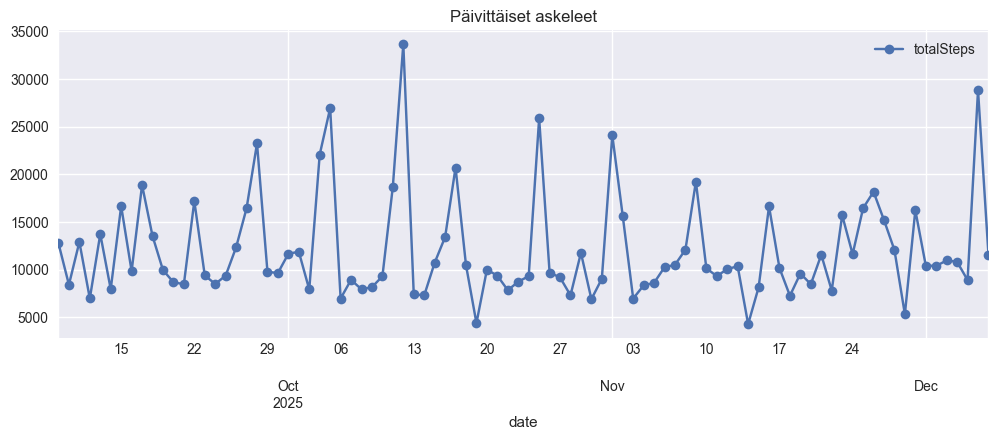

In [ ]:

df.plot(x="date", y="totalSteps", marker="o", figsize=(12, 4))
plt.title("Päivittäiset askeleet")
plt.grid(True)
plt.show()

**Päivittäiset kokonaiskalorit**

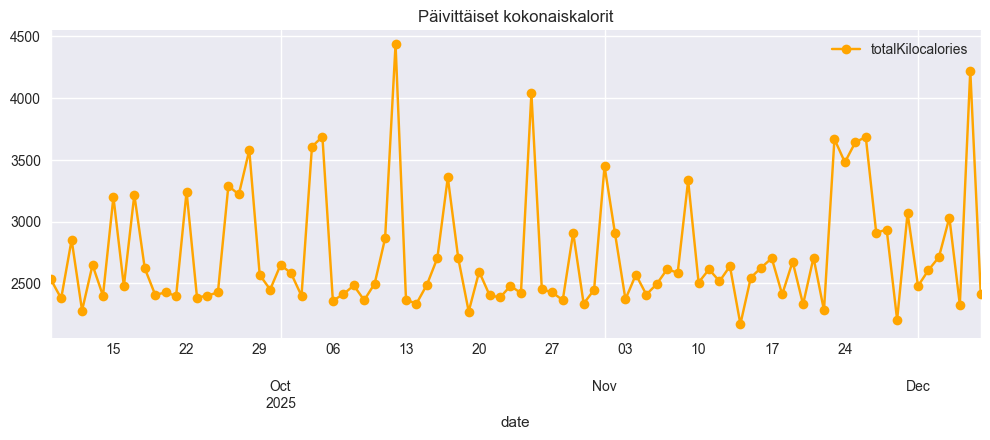

In [ ]:

df.plot(x="date", y="totalKilocalories", marker="o", color="orange", figsize=(12, 4))
plt.title("Päivittäiset kokonaiskalorit")
plt.grid(True)
plt.show()

**Body Battery: charged vs drained**

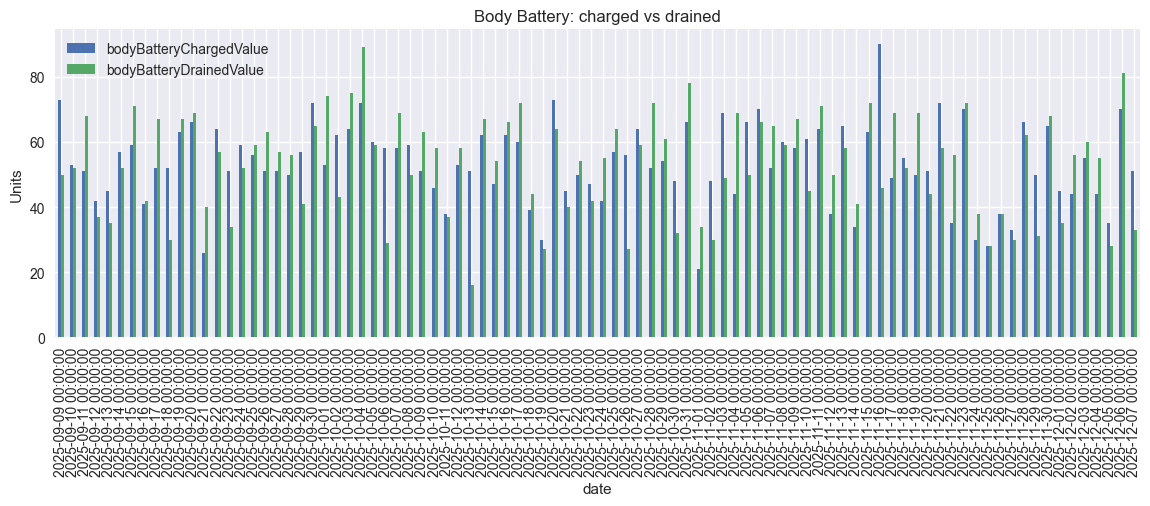

In [ ]:

cols = ["bodyBatteryChargedValue", "bodyBatteryDrainedValue"]
df.set_index("date")[cols].plot(kind="bar", figsize=(14, 4))
plt.title("Body Battery: charged vs drained")
plt.ylabel("Units")
plt.grid(True, axis="y")
plt.show()

**Hengitys**

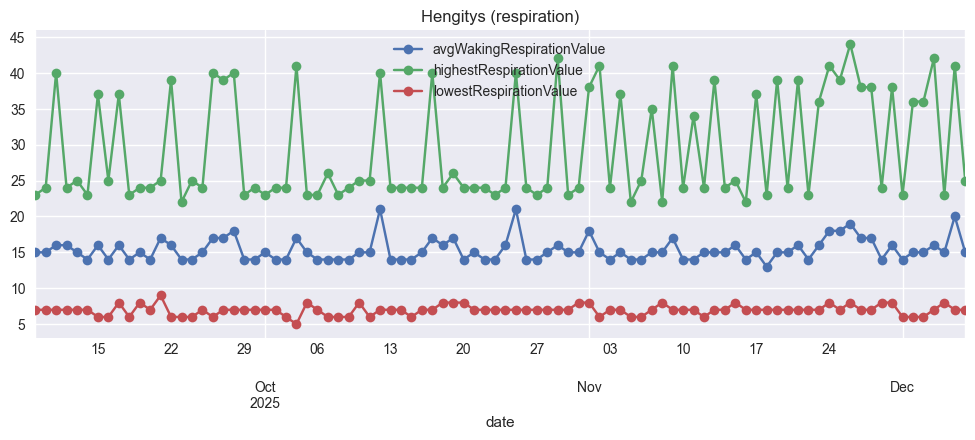

In [ ]:

resp_cols = ["avgWakingRespirationValue", "highestRespirationValue", "lowestRespirationValue"]
existing_resp_cols = [c for c in resp_cols if c in df.columns]

if existing_resp_cols:
    df.plot(x="date", y=existing_resp_cols, marker="o", figsize=(12, 4))
    plt.title("Hengitys (respiration)")
    plt.grid(True)
    plt.show()

In [18]:
import pandas as pd

df_hr = pd.read_csv("garmin_hr_timeseries.csv")
df_hr.head()
print(type(df_hr.loc[0, "raw_hr_data"]))
print(df_hr.loc[0, "raw_hr_data"][:500])

<class 'str'>
{'userProfilePK': 5652846, 'calendarDate': '2025-09-09', 'startTimestampGMT': '2025-09-08T21:00:00.0', 'endTimestampGMT': '2025-09-09T21:00:00.0', 'startTimestampLocal': '2025-09-09T00:00:00.0', 'endTimestampLocal': '2025-09-10T00:00:00.0', 'maxHeartRate': 120, 'minHeartRate': 47, 'restingHeartRate': 56, 'lastSevenDaysAvgRestingHeartRate': 61, 'heartRateValueDescriptors': [{'key': 'timestamp', 'index': 0}, {'key': 'heartrate', 'index': 1}], 'heartRateValues': [[1757365200000, 79], [1757365320000


In [19]:
import ast
import pandas as pd

# Lue raaka HR-data
df_hr_raw = pd.read_csv("garmin_hr_timeseries.csv")

# Muunna raw_hr_data (string) oikeaksi Python-objektiksi
def parse_raw_hr(row):
    try:
        return ast.literal_eval(row)
    except Exception:
        return None

df_parsed = df_hr_raw.copy()
df_parsed["raw_obj"] = df_parsed["raw_hr_data"].apply(parse_raw_hr)

# Riveistä, joissa ei ole kunnollista dictiä, ei jatketa
df_parsed = df_parsed[df_parsed["raw_obj"].notnull()]

# Purkaa heartRateValues -> pitkä taulukko (timestamp, bpm, date, restingHR, maxHR, minHR)
records = []
for _, row in df_parsed.iterrows():
    obj = row["raw_obj"]
    values = obj.get("heartRateValues") or []
    resting = obj.get("restingHeartRate")
    max_hr = obj.get("maxHeartRate")
    min_hr = obj.get("minHeartRate")
    date_str = obj.get("calendarDate") or row["date"]
    for ts_ms, bpm in values:
        records.append(
            {
                "date": date_str,
                "timestamp_ms": ts_ms,
                "bpm": bpm,
                "restingHeartRate": resting,
                "maxHeartRate": max_hr,
                "minHeartRate": min_hr,
            }
        )

df_hr_ts = pd.DataFrame(records)
df_hr_ts["timestamp"] = pd.to_datetime(df_hr_ts["timestamp_ms"], unit="ms")
df_hr_ts = df_hr_ts.sort_values("timestamp")

df_hr_ts.head()

,date,timestamp_ms,bpm,restingHeartRate,maxHeartRate,minHeartRate,timestamp
0,2025-09-09,1757365200000,79.0,56,120,47,2025-09-08 21:00:00
1,2025-09-09,1757365320000,87.0,56,120,47,2025-09-08 21:02:00
2,2025-09-09,1757365440000,85.0,56,120,47,2025-09-08 21:04:00
3,2025-09-09,1757365560000,69.0,56,120,47,2025-09-08 21:06:00
4,2025-09-09,1757365680000,68.0,56,120,47,2025-09-08 21:08:00


**Esimerkki: yhden yön HR (klo 00–06 paikallista aikaa) yhdelle päivälle**

In [ ]:

day = df_hr_ts["date"].iloc[0]  # vaihda halutuksi päiväksi
mask = (df_hr_ts["date"] == day) & (df_hr_ts["timestamp"].dt.hour.between(0, 5))
night_hr = df_hr_ts[mask]

night_hr[["timestamp", "bpm"]].head()

,timestamp,bpm
90,2025-09-09 00:00:00,66.0
91,2025-09-09 00:02:00,64.0
92,2025-09-09 00:04:00,63.0
93,2025-09-09 00:06:00,62.0
94,2025-09-09 00:08:00,62.0


**Yöajan (00–06) bpm:n keskihajonta per päivä**

In [ ]:

df_hr_ts["hour"] = df_hr_ts["timestamp"].dt.hour
night = df_hr_ts[df_hr_ts["hour"].between(0, 5)]

night_hrv = (
    night.groupby("date")["bpm"]
    .agg(["mean", "std", "min", "max"])
    .rename(columns={"std": "bpm_std_night"})
    .reset_index()
)

night_hrv.head()

,date,mean,bpm_std_night,min,max
0,2025-09-09,64.788889,10.484886,55.0,102.0
1,2025-09-10,68.811111,12.049613,57.0,108.0
2,2025-09-11,67.311111,9.859510,57.0,97.0
3,2025-09-12,67.011111,7.602549,58.0,98.0
4,2025-09-13,71.727778,10.400811,61.0,115.0


1. Yö-HRV yhdistettynä päivätason datan kanssa

In [22]:
# Varmista että molemmissa date on datetime / sama formaatti
df["date"] = pd.to_datetime(df["date"])
night_hrv["date"] = pd.to_datetime(night_hrv["date"])

df_merged = df.merge(night_hrv, on="date")

df_merged[["date", "bpm_std_night", "bodyBatteryChargedValue", "totalSteps"]].head()

,date,bpm_std_night,bodyBatteryChargedValue,totalSteps
0,2025-09-09,10.484886,73,12766
1,2025-09-10,12.049613,53,8416
2,2025-09-11,9.859510,51,12904
3,2025-09-12,7.602549,42,6972
4,2025-09-13,10.400811,45,13733


2. Kuva: yö-HRV vs. body battery

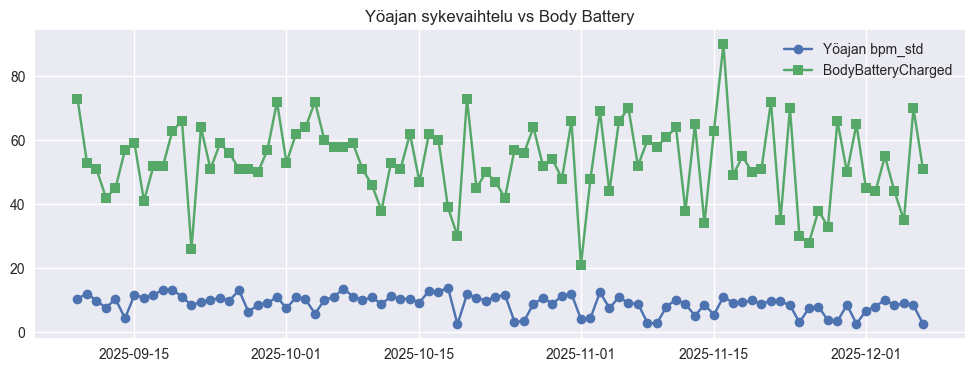

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(df_merged["date"], df_merged["bpm_std_night"], marker="o", label="Yöajan bpm_std")
plt.plot(df_merged["date"], df_merged["bodyBatteryChargedValue"], marker="s", label="BodyBatteryCharged")
plt.title("Yöajan sykevaihtelu vs Body Battery")
plt.grid(True)
plt.legend()
plt.show()

3. Yksinkertainen korrelaatiotaulukko

In [24]:
cols = ["bpm_std_night", "bodyBatteryChargedValue", "totalSteps", "totalKilocalories"]
df_merged[cols].corr()

,bpm_std_night,bodyBatteryChargedValue,totalSteps,totalKilocalories
bpm_std_night,1.000000,0.212261,-0.166021,-0.218627
bodyBatteryChargedValue,0.212261,1.000000,0.091181,0.020944
totalSteps,-0.166021,0.091181,1.000000,0.914573
totalKilocalories,-0.218627,0.020944,0.914573,1.000000


**Liukuvat keskiarvot ja trendit**

In [27]:
# Varmista aikajärjestys
df_merged = df_merged.sort_values("date")

# 7 päivän liukuvat keskiarvot
df_merged["bpm_std_night_7d"] = df_merged["bpm_std_night"].rolling(7, min_periods=3).mean()
df_merged["bodyBatteryCharged_7d"] = df_merged["bodyBatteryChargedValue"].rolling(7, min_periods=3).mean()
df_merged["totalSteps_7d"] = df_merged["totalSteps"].rolling(7, min_periods=3).mean()
df_merged["totalKilocalories_7d"] = df_merged["totalKilocalories"].rolling(7, min_periods=3).mean()

df_merged[["date", "bpm_std_night_7d", "bodyBatteryCharged_7d", "totalSteps_7d"]].head()

,date,bpm_std_night_7d,bodyBatteryCharged_7d,totalSteps_7d
0,2025-09-09,NaN,NaN,NaN
1,2025-09-10,NaN,NaN,NaN
2,2025-09-11,10.798003,59.00,11362.0
3,2025-09-12,9.999140,54.75,10264.5
4,2025-09-13,10.079474,52.80,10958.2


**Yö-HRV-trendi vs. body battery**

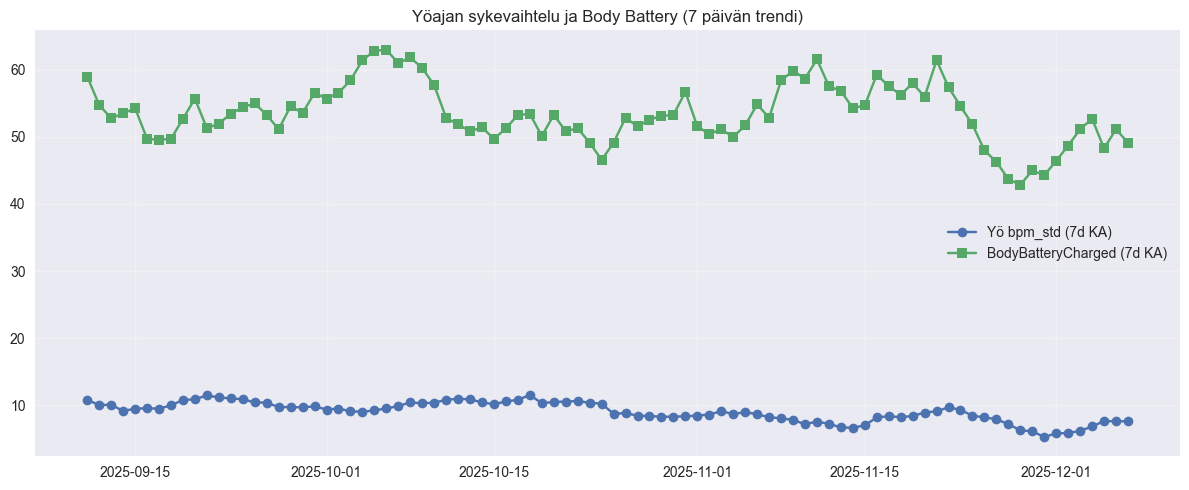

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(df_merged["date"], df_merged["bpm_std_night_7d"], marker="o", label="Yö bpm_std (7d KA)")
plt.plot(df_merged["date"], df_merged["bodyBatteryCharged_7d"], marker="s", label="BodyBatteryCharged (7d KA)")
plt.title("Yöajan sykevaihtelu ja Body Battery (7 päivän trendi)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Scatter-kuvat kuormituksen ja yö-HRV:n suhteesta**

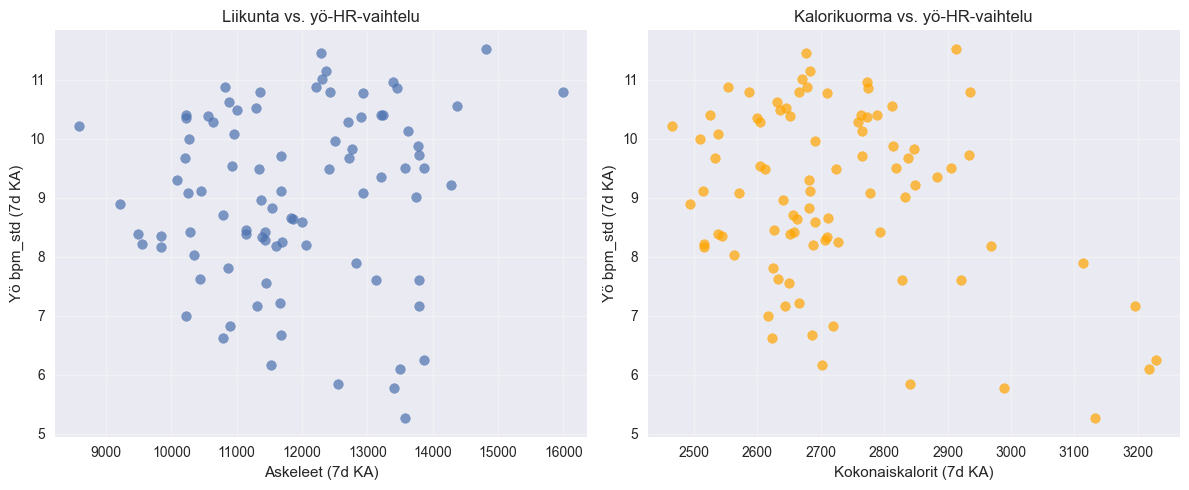

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Steps vs night HRV
axes[0].scatter(df_merged["totalSteps_7d"], df_merged["bpm_std_night_7d"], alpha=0.7)
axes[0].set_xlabel("Askeleet (7d KA)")
axes[0].set_ylabel("Yö bpm_std (7d KA)")
axes[0].set_title("Liikunta vs. yö-HR-vaihtelu")
axes[0].grid(True, alpha=0.3)

# Calories vs night HRV
axes[1].scatter(df_merged["totalKilocalories_7d"], df_merged["bpm_std_night_7d"], alpha=0.7, color="orange")
axes[1].set_xlabel("Kokonaiskalorit (7d KA)")
axes[1].set_ylabel("Yö bpm_std (7d KA)")
axes[1].set_title("Kalorikuorma vs. yö-HR-vaihtelu")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ML Xgboost

**Solu 1 – Feature-matriisi ja train/test-jako**

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Tehdään uusi taulu mallia varten
df_feat = df_merged.copy().sort_values("date")

# Tavoite: seuraavan päivän bodyBatteryChargedValue
df_feat["target_bodyBattery_next"] = df_feat["bodyBatteryChargedValue"].shift(-1)
df_feat = df_feat.dropna(subset=["target_bodyBattery_next", "bpm_std_night_7d"])

feature_cols = [
    "bpm_std_night_7d",
    "bpm_std_night",
    "totalSteps_7d",
    "totalKilocalories_7d",
    "totalSteps",
    "totalKilocalories",
    "restingHeartRate",
]

# Poistetaan mahdolliset puuttuvat sarakkeet (jos jokin puuttuu datasta)
feature_cols = [c for c in feature_cols if c in df_feat.columns]

X = df_feat[feature_cols]
y = df_feat["target_bodyBattery_next"]

# Aika-sarjassa kannattaa pitää viimeiset päivät testissä
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=False  # ei sekoiteta aikajärjestystä
)

X_train.shape, X_test.shape

((65, 7), (22, 7))

**Solu 2 – XGBoost-malli ja tulosten arviointi**

MAE: 11.934031919999557
R2: -0.010783675394526737


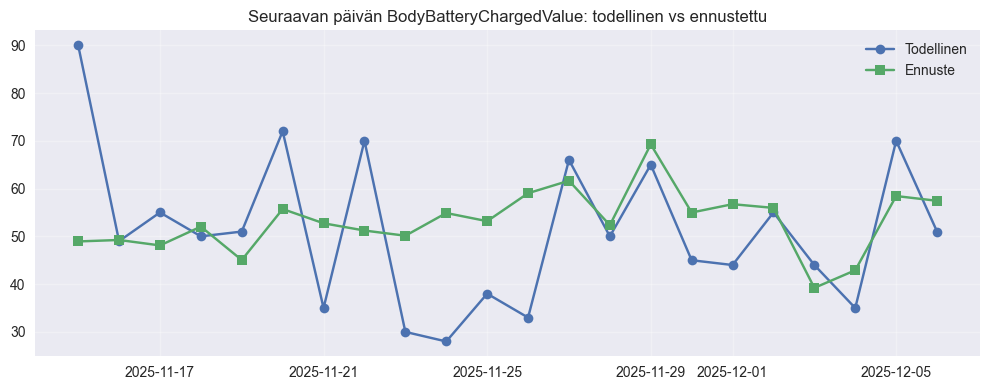

restingHeartRate: 0.222
totalKilocalories: 0.161
bpm_std_night: 0.148
totalSteps: 0.146
totalSteps_7d: 0.132
bpm_std_night_7d: 0.106
totalKilocalories_7d: 0.086


In [32]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
)

# Jos treenidataa on liian vähän, ei kannata ajaa mallia
if len(X_train) == 0 or len(X_test) == 0:
    print("Liian vähän havaintoja train/test-jakoon – lisää päiviä tai pienennä test_size-arvoa.")
else:
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("MAE:", mae)
    print("R2:", r2)

    # Turvallinen tapa hakea päivämäärät: käytä samoja indeksejä kuin X_test:ssä
    dates_test = df_feat.loc[X_test.index, "date"]

    plt.figure(figsize=(10, 4))
    plt.plot(dates_test, y_test.values, label="Todellinen", marker="o")
    plt.plot(dates_test, y_pred, label="Ennuste", marker="s")
    plt.title("Seuraavan päivän BodyBatteryChargedValue: todellinen vs ennustettu")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Tärkeysjärjestys piirteille
    importance = model.feature_importances_
    for col, imp in sorted(zip(feature_cols, importance), key=lambda x: -x[1]):
        print(f"{col}: {imp:.3f}")